# Quantum Teleportation

1. Circuit Visualisation

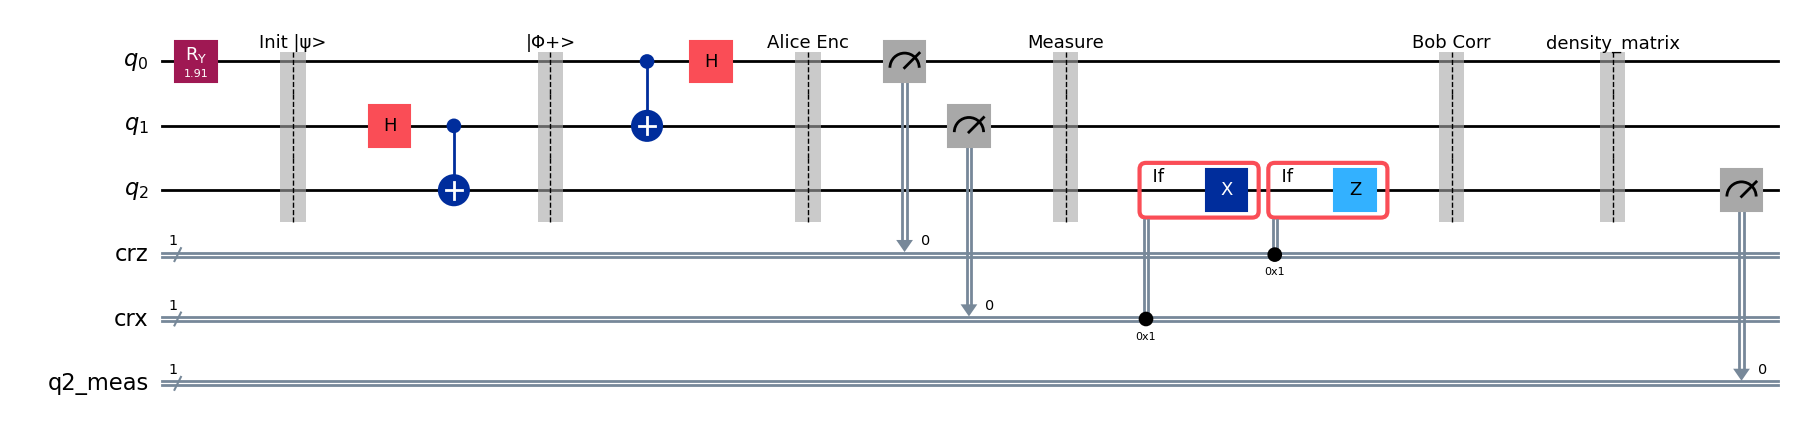

2. Quantum State Representation

Initial Statevector (Qubit 0 prior to teleportation):


<IPython.core.display.Latex object>


Final DensityMatrix (Qubit 2 after corrections):


<IPython.core.display.Latex object>

3. State Visualisation

Initial State (Bloch Sphere):


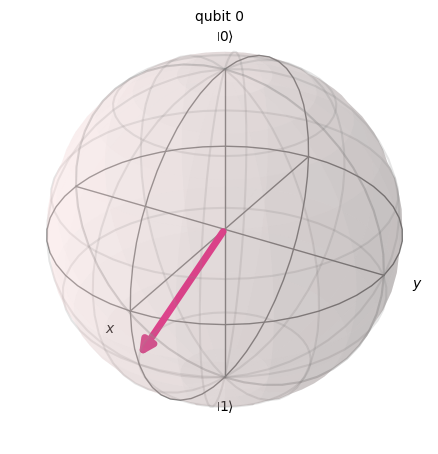


Final State (Bloch Sphere):


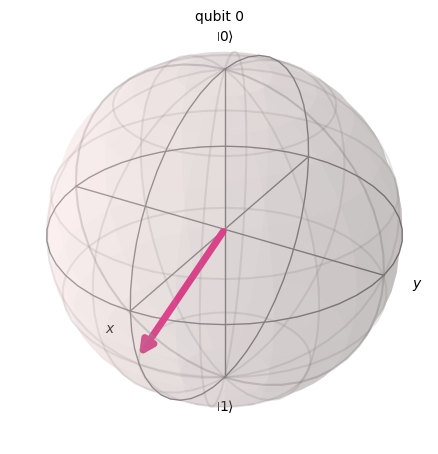


Final State (Q-Sphere):


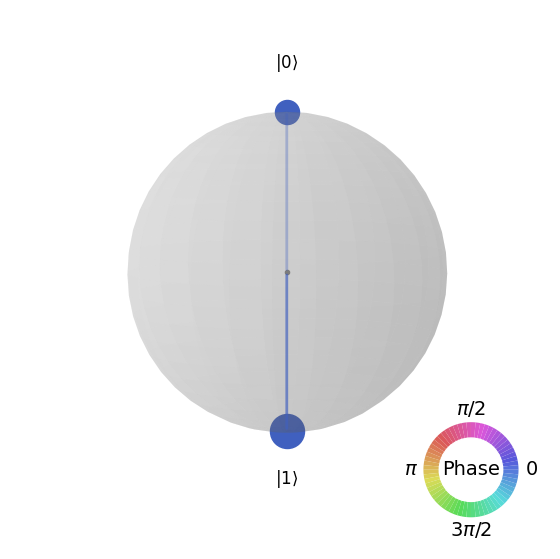

4. Measurement Analysis

Raw measurement counts: {'0 0 1': 83, '1 1 0': 167, '1 0 0': 183, '0 1 1': 76, '1 1 1': 166, '1 0 1': 178, '0 1 0': 93, '0 0 0': 78}


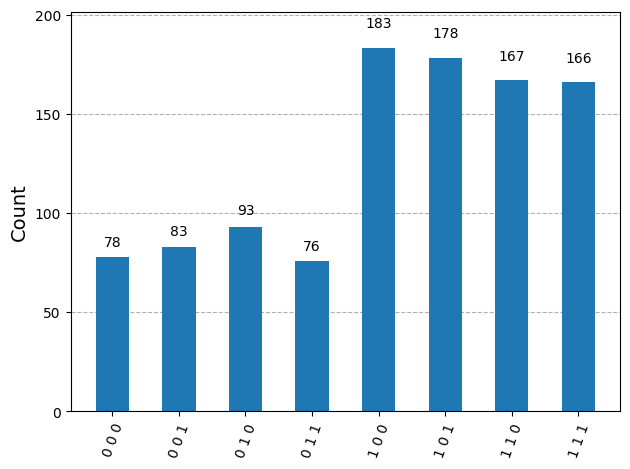

5. Verification

Teleportation Fidelity = 1.000000
Success: The state was teleported perfectly.


In [72]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from IPython.display import display, Markdown

# 1. Set up Registers & Circuit
qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")
cr_final = ClassicalRegister(1, name="q2_meas")
qc = QuantumCircuit(qr, crz, crx, cr_final)

# 2. Initialise Qubit 0 to the arbitrary state |ψ>
theta = 2 * np.arccos(1 / np.sqrt(3))
qc.ry(theta, 0)
qc.barrier(label="Init |ψ>")

# Create a standalone 1-qubit reference state for the fidelity check
reference_circuit = QuantumCircuit(1)
reference_circuit.ry(theta, 0)
initial_state = Statevector(reference_circuit)


# 3. Create shared Bell pair (|Φ+>) between Alice (Q1) and Bob (Q2)
qc.h(1)
qc.cx(1, 2)
qc.barrier(label="|Φ+>")

# 4. Alice encodes the state
qc.cx(0, 1)
qc.h(0)
qc.barrier(label="Alice Enc")

# 5. Alice measures her qubits
qc.measure(0, crz)
qc.measure(1, crx)
qc.barrier(label="Measure")

# 6. Bob applies dynamic corrections based on Alice's classical bits
with qc.if_test((crx, 1)):
    qc.x(2)
with qc.if_test((crz, 1)):
    qc.z(2)
qc.barrier(label="Bob Corr")

# Save the full density matrix before the final measurement collapses it
qc.save_density_matrix()

# 7. Bob measures his qubit to verify the final state (optional, for histogram)
qc.measure(2, cr_final)

# 8. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Quantum State Representation"))
print("Initial Statevector (Qubit 0 prior to teleportation):")
display(initial_state.draw('latex'))

# Extract Bob's final state by tracing out Alice's qubits (Q0 and Q1)
rho_full = result.data()['density_matrix']
rho_bob = partial_trace(rho_full, [0, 1])

print("\nFinal DensityMatrix (Qubit 2 after corrections):")
display(rho_bob.draw('latex'))

display(Markdown("3. State Visualisation"))
print("Initial State (Bloch Sphere):")
display(plot_bloch_multivector(initial_state))

print("\nFinal State (Bloch Sphere):")
display(plot_bloch_multivector(rho_bob))

print("\nFinal State (Q-Sphere):")
display(plot_state_qsphere(rho_bob))

display(Markdown("4. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# Note: Operator(qc) is omitted here because mid-circuit measurements 
# and dynamic resets make the overall circuit non-unitary.

display(Markdown("5. Verification"))
fidelity = state_fidelity(initial_state, rho_bob)
print(f"Teleportation Fidelity = {fidelity:.6f}")
if np.isclose(fidelity, 1.0):
    print("Success: The state was teleported perfectly.")
else:
    print("Warning: Teleportation fidelity is less than 1.")